一.lightgbm模型

原始数据形状: (4458, 28)
删除目标缺失后形状: (4458, 28)
Genres 类别数: 23
Content rating 类别数: 15
最终特征矩阵形状: (4458, 56)
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\24879\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\24879\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\24879\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
c:\Users\24879\AppData\Local\Programs\Python\Python310\lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical

最佳参数: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.5, 'num_leaves': 50, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 11, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
最佳交叉验证 R² (对数尺度): 0.5155390324129808

训练集 R² (对数尺度): 0.8295
验证集 R² (对数尺度): 0.5155
测试集 R² (对数尺度): 0.5051
测试集 R² (原始票房): 0.6862


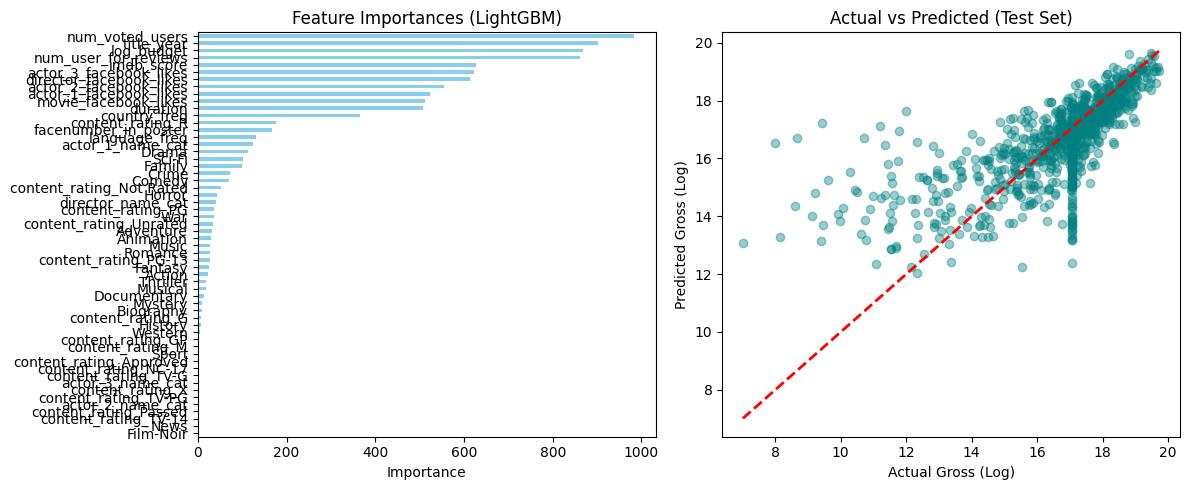

模型已保存为 lightgbm_model.pkl


In [1]:
import os
os.environ['PYTHONUTF8'] = '1'

import sys
import codecs

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib

# ==================== 1. 加载数据 ====================
df = pd.read_csv('movie2_clean.csv')
print("原始数据形状:", df.shape)

target = 'gross'
df = df.dropna(subset=[target])
print("删除目标缺失后形状:", df.shape)

# ==================== 2. 基础数值特征 ====================
numeric_features = ['budget', 'director_facebook_likes', 'actor_1_facebook_likes',
                    'actor_2_facebook_likes', 'actor_3_facebook_likes', 'movie_facebook_likes',
                    'num_voted_users', 'num_user_for_reviews', 'imdb_score']

extra_numeric = ['duration', 'title_year', 'facenumber_in_poster']
for col in extra_numeric:
    if col in df.columns:
        numeric_features.append(col)

for col in numeric_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

if 'budget' in df.columns:
    df['log_budget'] = np.log1p(df['budget'])
    numeric_features.append('log_budget')
    if 'budget' in numeric_features:
        numeric_features.remove('budget')

# ==================== 3. 处理 genres 多标签 ====================
multi_label_feature = 'genres'
df['genres_list'] = df[multi_label_feature].str.split('|')
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)
print("Genres 类别数:", len(mlb.classes_))

# ==================== 4. 处理 content_rating ====================
df['content_rating'] = df['content_rating'].fillna('Unknown')
content_rating_dummies = pd.get_dummies(df['content_rating'], prefix='content_rating')
print("Content rating 类别数:", content_rating_dummies.shape[1])

# ==================== 5. 频数编码 (country, language) ====================
categorical_freq = ['country', 'language']
for col in categorical_freq:
    if col in df.columns:
        freq_map = df[col].value_counts().to_dict()
        df[col + '_freq'] = df[col].map(freq_map).fillna(0)
        numeric_features.append(col + '_freq')

# ==================== 6. 处理导演和演员作为类别特征 ====================
categorical_cols = ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')
        le = LabelEncoder()
        df[col + '_cat'] = le.fit_transform(df[col])

cat_encoded_cols = [col + '_cat' for col in categorical_cols if col in df.columns]
X_numeric = df[numeric_features].copy()
X = pd.concat([X_numeric, genres_df, content_rating_dummies, df[cat_encoded_cols]], axis=1)

X = X.astype(float)

print("最终特征矩阵形状:", X.shape)

# ==================== 7. 目标变量对数变换 ====================
y_log = np.log1p(df[target])

# ==================== 8. 划分训练集和测试集 ====================
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

categorical_feature_indices = [X_train.columns.get_loc(col) for col in cat_encoded_cols if col in X_train.columns]

# ==================== 9. LightGBM 模型与调优（保持原样） ====================
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9, 11],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [31, 50, 70, 90],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0]
}

lgb_model = lgb.LGBMRegressor(
    random_state=42,
    n_jobs=1,
    verbose=-1,
    categorical_feature=categorical_feature_indices
)

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    verbose=1,
    n_jobs=1,
    random_state=42
)

random_search.fit(X_train, y_train_log)

print("最佳参数:", random_search.best_params_)
print("最佳交叉验证 R² (对数尺度):", random_search.best_score_)

best_lgb = random_search.best_estimator_

# ==================== 10. 预测与评估（修改输出格式以匹配随机森林） ====================
# 训练集预测
y_train_pred_log = best_lgb.predict(X_train)
train_r2_log = r2_score(y_train_log, y_train_pred_log)

# 测试集预测
y_test_pred_log = best_lgb.predict(X_test)
test_r2_log = r2_score(y_test_log, y_test_pred_log)

# 原始票房 R²
y_test_original = np.expm1(y_test_log)
y_test_pred_original = np.expm1(y_test_pred_log)
test_r2_orig = r2_score(y_test_original, y_test_pred_original)

# 使用交叉验证的平均 R² 作为验证集指标（模拟随机森林的验证集）
val_r2_log = random_search.best_score_

# 格式化输出（与随机森林完全一致）
print("\n" + "="*30)
print(f"训练集 R² (对数尺度): {train_r2_log:.4f}")
print(f"验证集 R² (对数尺度): {val_r2_log:.4f}")
print(f"测试集 R² (对数尺度): {test_r2_log:.4f}")
print(f"测试集 R² (原始票房): {test_r2_orig:.4f}")
print("="*30)

# ==================== 11. 可视化（双图：特征重要性 + 预测vs真实） ====================
plt.figure(figsize=(12, 5))

# 左图：特征重要性（全部特征，按重要性排序）
plt.subplot(1, 2, 1)
importances = pd.Series(best_lgb.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=True)
importances_sorted.plot(kind='barh', color='skyblue')
plt.title('Feature Importances (LightGBM)')
plt.xlabel('Importance')

# 右图：测试集预测值 vs 真实值（对数尺度）
plt.subplot(1, 2, 2)
plt.scatter(y_test_log, y_test_pred_log, alpha=0.4, color='teal')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
plt.xlabel('Actual Gross (Log)')
plt.ylabel('Predicted Gross (Log)')
plt.title('Actual vs Predicted (Test Set)')

plt.tight_layout()
plt.show()

# ==================== 12. 保存模型 ====================
joblib.dump(best_lgb, 'lightgbm_model.pkl')
print("模型已保存为 lightgbm_model.pkl")